In [1]:
# Core imports (PyTorch)
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim # For optimization algorithms
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from PIL import Image # For image processing
from mri_brain_tumor.utils.preprocessing import preprocess_image 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Use GPU if available
print('PyTorch version:', torch.__version__) 
print('Device:', device) # Print device information

PyTorch version: 2.4.1
Device: cpu


In the next cell, some basic parameters are defined to make life easier when accessing various types of data (i.e. raw vs processed, training vs validation, etc). Then, the `train_transforms` and `val_transforms` objects do a subset of the following steps:
- ensures all image sizes match expected dimensions
- randomly flips images left-right with 50% probability
- randomly rotates images
- converts images to a pytorch tensor and also scales pixel values from [0, 255] to [0, 1]
- normalizes each RBG channel (pixel val - mean)/std

The main difference between `train_transforms` and `val_transforms` is that the latter skips the augmentation steps. The values [0.485, 0.456, 0.406], [0.229, 0.224, 0.225] are common values used when training pre-existing models such as Resnet. The transforms make the model robust to variations in images such as slight rotations in the image.

In [2]:
# Data paths and transforms (adjust paths if needed)
BASE_DIR = os.path.join('..', 'data', 'processed')
TRAIN_DIR = os.path.join(BASE_DIR, 'Training')
VAL_DIR = os.path.join(BASE_DIR, 'Validation')
IMG_SIZE = 224 # image sizes are 224x224
BATCH_SIZE = 16

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# create datasets
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_ds = datasets.ImageFolder(VAL_DIR, transform=val_transforms)
# create dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# print dataset info
print('Classes:', train_ds.class_to_idx)
print('Train samples:', len(train_ds), 'Val samples:', len(val_ds))

Classes: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Train samples: 2035 Val samples: 511


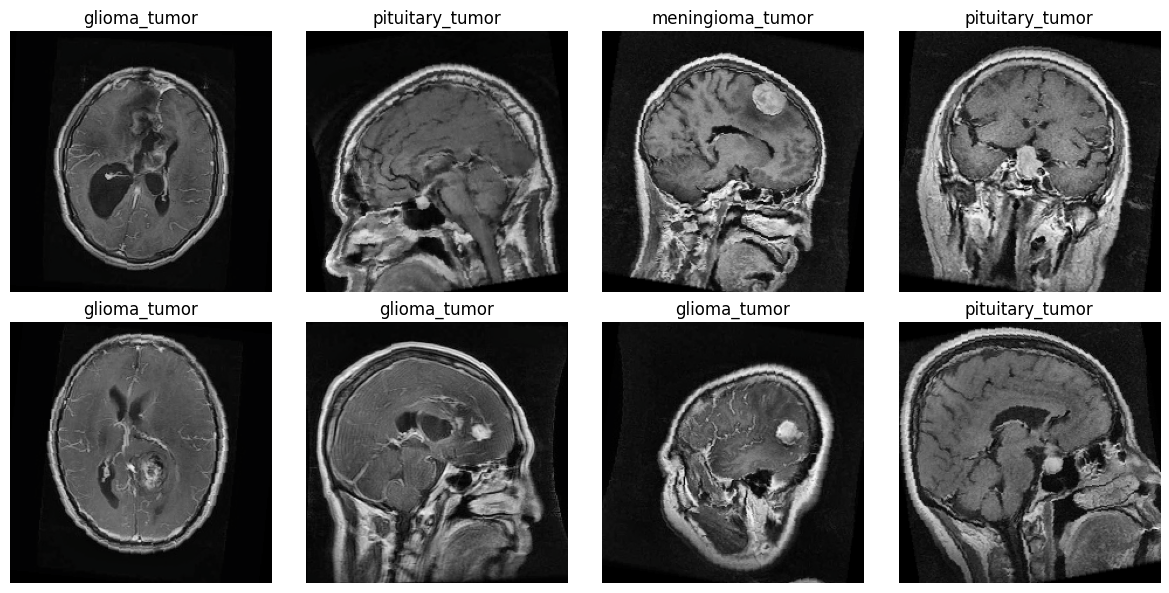

In [5]:
# Show a few sample images from the training dataset
def imshow_tensor(img_tensor, ax=None, title=None):
    """
    Displays a tensor as an image on the provided Matplotlib axis.
    Args:
        img_tensor (torch.Tensor): Image tensor to display.
        ax (matplotlib.axes.Axes, optional): Axis to draw the image on. If None uses plt.
        title (str, optional): Title for the image. Defaults to None.
    """

    # ensure tensor is on CPU and convert to numpy
    img = img_tensor.cpu().numpy().transpose((1,2,0)) 
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    if ax is None:
        plt.imshow(img)
        if title: plt.title(title)
        plt.axis('off')
    else:
        ax.imshow(img)
        if title: ax.set_title(title)
        ax.axis('off')


data_iter = iter(train_loader) # get a batch of training data
images, labels = next(data_iter) # get images and labels from the batch
# plot the images in a grid
fig, axes = plt.subplots(2,4, figsize=(12,6))
# use the dataset's ordered class list and label.item() to index safely
for i, ax in enumerate(axes.ravel()):
    im = images[i]
    lbl = labels[i].item() if hasattr(labels[i], 'item') else int(labels[i])
    class_name = train_ds.classes[lbl]
    imshow_tensor(im, ax=ax, title=class_name)
plt.tight_layout()
plt.show()